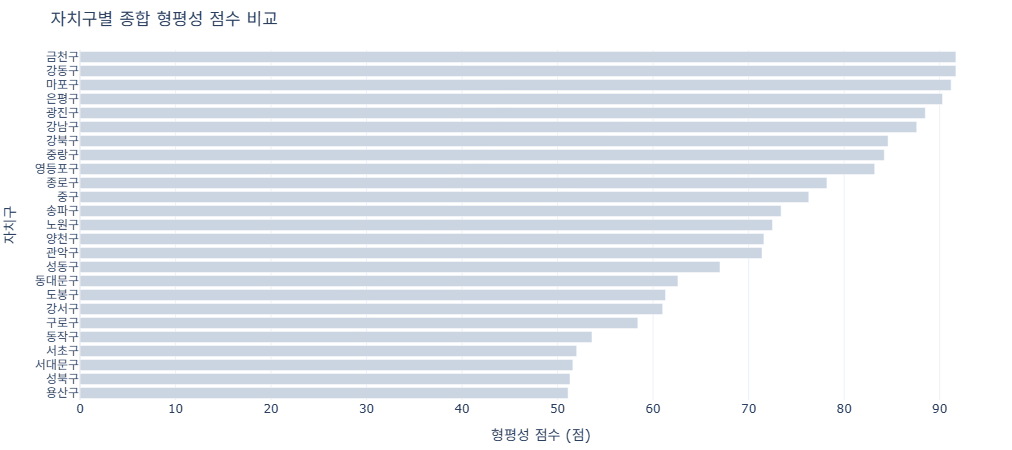

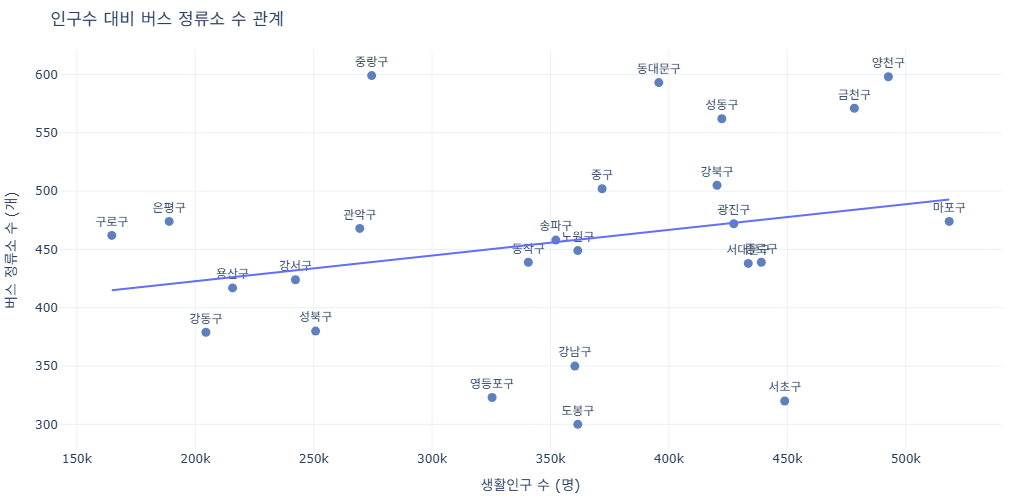

In [9]:
import random
import visualizer
import importlib
importlib.reload(visualizer)
from visualizer import Visualizer
from shapely.geometry import Polygon

# 서울시 25개 자치구 전체 목록
seoul_districts = [
    "강남구", "강동구", "강북구", "강서구", "관악구", "광진구", "구로구", "금천구",
    "노원구", "도봉구", "동대문구", "동작구", "마포구", "서대문구", "서초구", "성동구",
    "성북구", "송파구", "양천구", "영등포구", "용산구", "은평구", "종로구", "중구", "중랑구"
]

class DummyDistrict:
    def __init__(self, code, name, area, pop, stops, score):
        self.district_code = str(code)
        self.district_name = name
        self.area = area
        self.living_population = pop
        self.bus_stop_count = stops
        self.population_date = "2026-10-10"
        self.geometry = Polygon([(126.9, 37.5), (126.9, 37.6), (127.0, 37.6), (127.0, 37.5)])
        self.score = score

    def calculate_stop_density(self): return self.bus_stop_count / self.area
    def calculate_stops_per_population(self): return (self.bus_stop_count / self.living_population) * 10000
    def calculate_equity_score(self, d_min, d_max, p_min, p_max): return self.score

# 25개 자치구 더미 객체 생성
districts_dict = {}
for idx, name in enumerate(seoul_districts, start=100):
    code = f"11{idx}"
    pop = random.randint(150000, 550000)
    stops = random.randint(300, 600)
    score = round(random.uniform(50.0, 95.0), 1)
    districts_dict[code] = DummyDistrict(code, name, 20.0, pop, stops, score)

# 전체 25개 자치구 시각화 생성
viz = Visualizer(districts=districts_dict, bus_stops=[])

# ★ 인자(selected_district_code)를 모두 빼고 호출 (강조 제거)
bar_fig = viz.create_bar_chart()
scatter_fig = viz.create_scatter_plot()

bar_fig.show()
scatter_fig.show()